# Round 1 — Market Analysis

Products: **ASH_COATED_OSMIUM**, **INTARIAN_PEPPER_ROOT**  
Days: -2, -1, 0

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

## 1. Load datasets

In [2]:
DATASET_DIR = Path('../prosperity_rust_backtester/datasets/round1')

DAYS = [-2, -1, 0]

prices_frames = []
trades_frames = []

for day in DAYS:
    p = pd.read_csv(DATASET_DIR / f'prices_round_1_day_{day}.csv', sep=';')
    t = pd.read_csv(DATASET_DIR / f'trades_round_1_day_{day}.csv', sep=';')
    p['day'] = day
    t['day'] = day
    prices_frames.append(p)
    trades_frames.append(t)

prices = pd.concat(prices_frames, ignore_index=True)
trades = pd.concat(trades_frames, ignore_index=True)

# Synthetic global timestamp (each day has timestamps 0..999_900 in steps of 100)
prices['global_ts'] = (prices['day'] + 2) * 1_000_000 + prices['timestamp']
trades['global_ts'] = (trades['day'] + 2) * 1_000_000 + trades['timestamp']

print('Prices shape:', prices.shape)
print('Trades shape:', trades.shape)
print('Products:', prices['product'].unique())
prices.head()

Prices shape: (60000, 18)
Trades shape: (2276, 9)
Products: ['INTARIAN_PEPPER_ROOT' 'ASH_COATED_OSMIUM']


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_ts
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0,0
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0,0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0,100
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0,100
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0,200


In [3]:
prices['mid_price'] = prices['mid_price'].replace(0.0, np.nan)

prices['mid_price'] = (
    prices
    .sort_values('global_ts')
    .groupby('product')['mid_price']
    .transform(lambda s: s.interpolate(method='linear').ffill().bfill())
)

print('Remaining zeros:', (prices['mid_price'] == 0).sum())
print('Remaining NaNs:', prices['mid_price'].isna().sum())

Remaining zeros: 0
Remaining NaNs: 0


## 2. Mid-price evolution

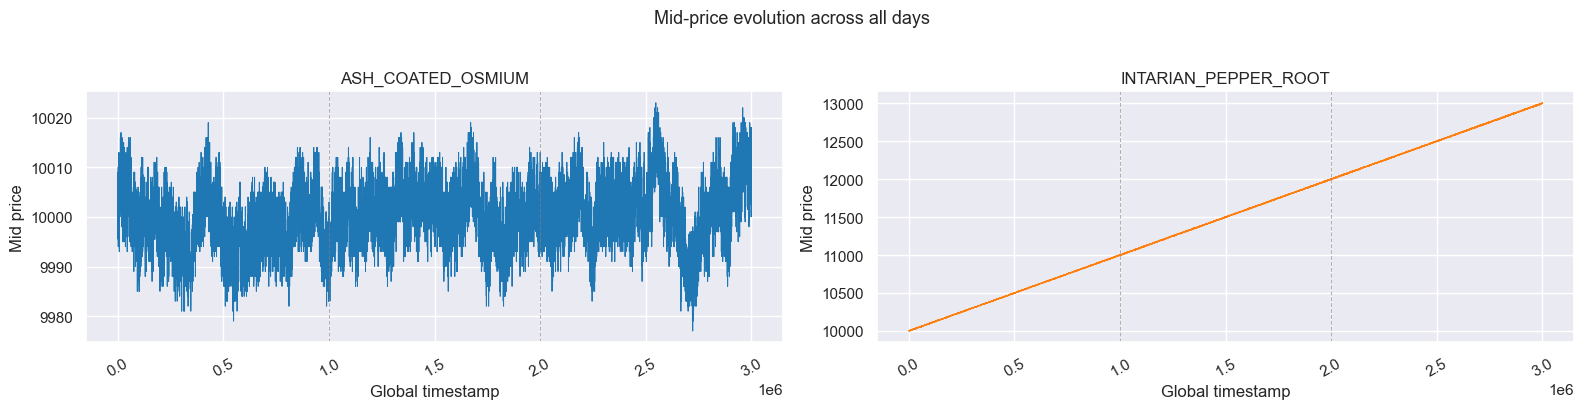

In [4]:
products = sorted(prices['product'].unique())
colors = sns.color_palette('tab10', len(products))

# products = sorted(prices['product'].unique())
# colors = sns.color_palette('tab10', len(products))

fig, axes = plt.subplots(1, len(products), sharey=False, figsize=(16, 4))

for ax, product, color in zip(axes, products, colors):
    df = prices[prices['product'] == product].sort_values('global_ts')
    ax.plot(df['global_ts'], df['mid_price'], lw=0.7, color=color)
    # Day separators
    for day in DAYS[1:]:
        sep = (day + 2) * 1_000_000
        ax.axvline(sep, color='gray', ls='--', lw=0.8, alpha=0.6)
    ax.set_title(product)
    ax.set_xlabel('Global timestamp')
    ax.set_ylabel('Mid price')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Mid-price evolution across all days', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Summary statistics per product per day

In [5]:
stats = (
    prices.groupby(['product', 'day'])['mid_price']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .round(2)
)
stats['range'] = stats['max'] - stats['min']
stats

mean     std      min      max  count   range
product              day                                                   
ASH_COATED_OSMIUM    -2    9998.17    5.22   9979.0  10019.0  10000    40.0
                     -1   10000.84    4.45   9982.0  10019.0  10000    37.0
                      0   10001.61    5.68   9977.0  10023.0  10000    46.0
INTARIAN_PEPPER_ROOT -2   10499.94  288.70   9998.5  11003.0  10000  1004.5
                     -1   11499.95  288.72  10995.0  12006.0  10000  1011.0
                      0   12499.94  288.72  11994.0  13007.0  10000  1013.0

## 4. Bid-ask spread

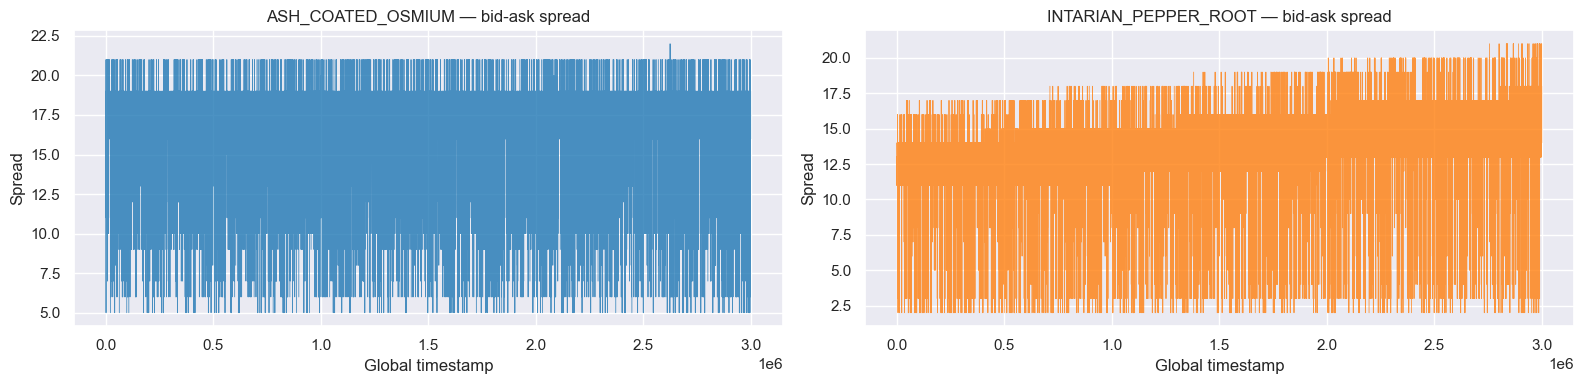

                        count   mean   std  min   25%   50%   75%   max
product                                                                
ASH_COATED_OSMIUM     27644.0  16.18  2.57  5.0  16.0  16.0  18.0  22.0
INTARIAN_PEPPER_ROOT  27688.0  13.05  2.63  2.0  12.0  13.0  14.0  21.0


In [6]:
prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']

fig, axes = plt.subplots(1, len(products), figsize=(16, 4))
for ax, product, color in zip(axes, products, colors):
    df = prices[prices['product'] == product].sort_values('global_ts')
    ax.plot(df['global_ts'], df['spread'], lw=0.6, color=color, alpha=0.8)
    ax.set_title(f'{product} — bid-ask spread')
    ax.set_xlabel('Global timestamp')
    ax.set_ylabel('Spread')

plt.tight_layout()
plt.show()

print(prices.groupby('product')['spread'].describe().round(2))

## 5. Bid / Ask volume at level 1

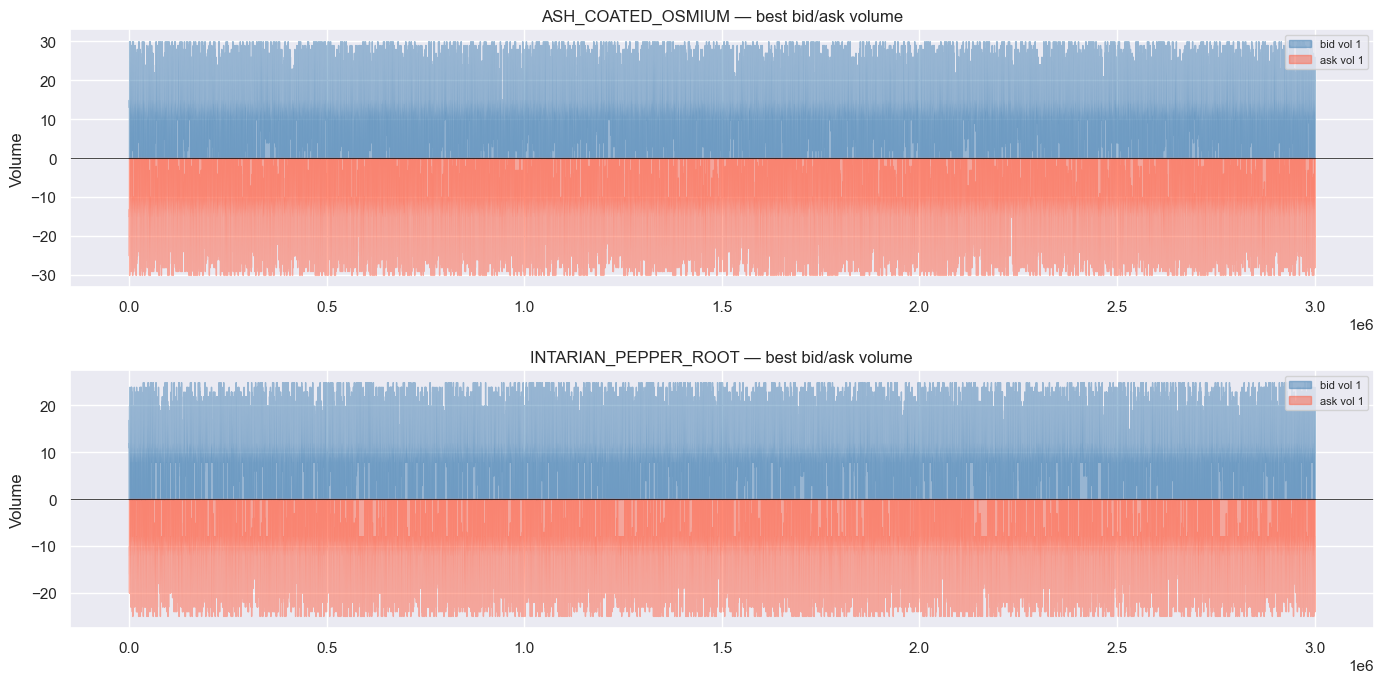

In [7]:
fig, axes = plt.subplots(len(products), 1, figsize=(14, 7), sharex=False)

for ax, product, color in zip(axes, products, colors):
    df = prices[prices['product'] == product].sort_values('global_ts')
    ax.fill_between(df['global_ts'], df['bid_volume_1'].fillna(0), alpha=0.5, label='bid vol 1', color='steelblue')
    ax.fill_between(df['global_ts'], -df['ask_volume_1'].fillna(0), alpha=0.5, label='ask vol 1', color='tomato')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(f'{product} — best bid/ask volume')
    ax.set_ylabel('Volume')
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Correlation matrix — mid-prices (aligned on global_ts)

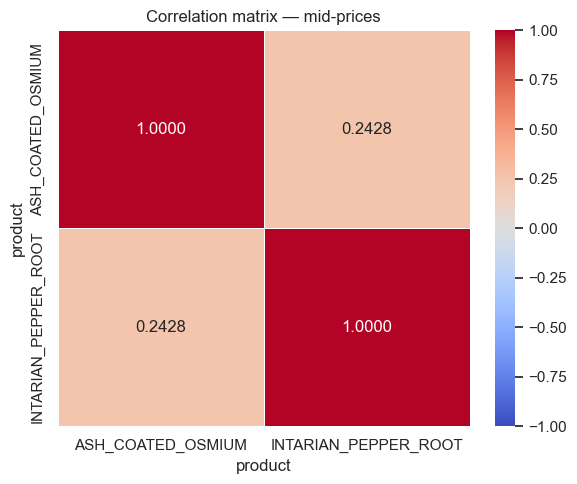

In [8]:
pivot = prices.pivot_table(index='global_ts', columns='product', values='mid_price')
pivot.ffill(inplace=True)

corr = pivot.corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, annot=True, fmt='.4f', cmap='coolwarm',
    vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title('Correlation matrix — mid-prices')
plt.tight_layout()
plt.show()

## 7. Rolling correlation (window = 500 ticks)

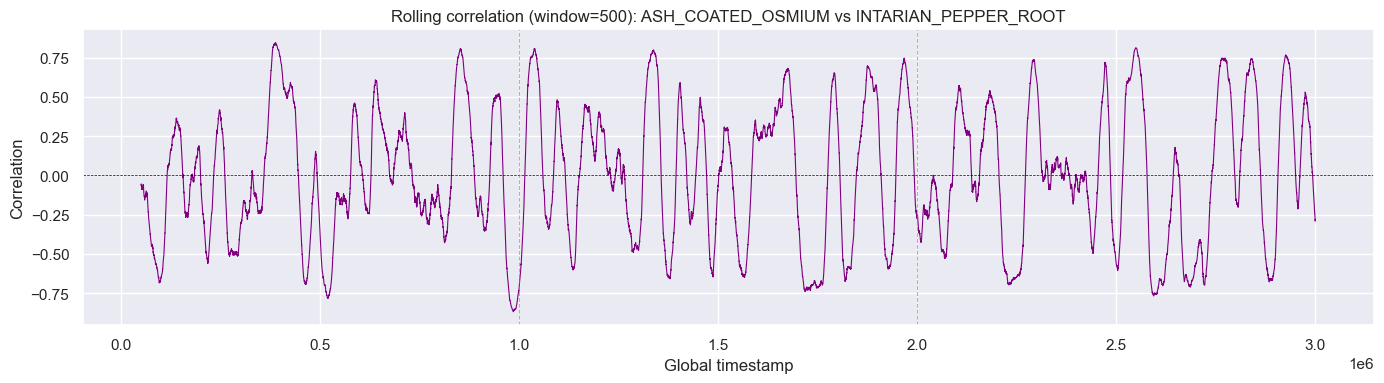

In [9]:
if len(products) >= 2:
    p0, p1 = products[0], products[1]
    rolling_corr = pivot[p0].rolling(500).corr(pivot[p1])

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(rolling_corr.index, rolling_corr.values, lw=0.8, color='purple')
    ax.axhline(0, color='black', lw=0.5, ls='--')
    for day in DAYS[1:]:
        ax.axvline((day + 2) * 1_000_000, color='gray', ls='--', lw=0.8, alpha=0.6)
    ax.set_title(f'Rolling correlation (window=500): {p0} vs {p1}')
    ax.set_xlabel('Global timestamp')
    ax.set_ylabel('Correlation')
    plt.tight_layout()
    plt.show()
else:
    print('Only one product — rolling correlation skipped.')

## 8. Returns and return correlation

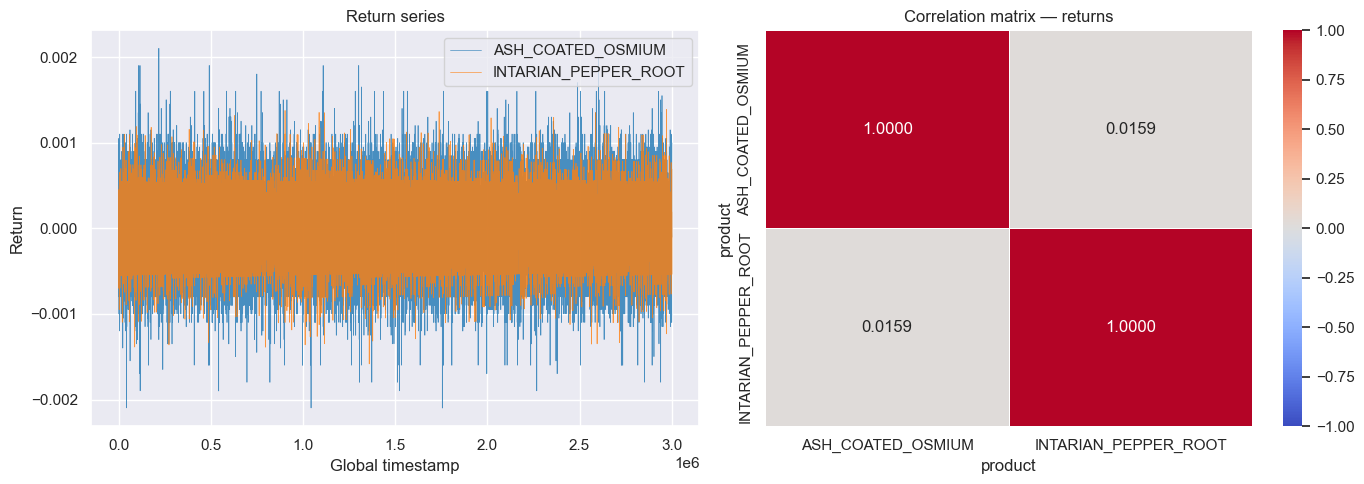

In [10]:
returns = pivot.pct_change().dropna()

ret_corr = returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Return time series
for product, color in zip(products, colors):
    axes[0].plot(returns.index, returns[product], lw=0.5, label=product, color=color, alpha=0.8)
axes[0].set_title('Return series')
axes[0].set_xlabel('Global timestamp')
axes[0].set_ylabel('Return')
axes[0].legend()

# Return correlation heatmap
sns.heatmap(
    ret_corr, annot=True, fmt='.4f', cmap='coolwarm',
    vmin=-1, vmax=1, linewidths=0.5, ax=axes[1]
)
axes[1].set_title('Correlation matrix — returns')

plt.tight_layout()
plt.show()

## 9. Trade activity

In [11]:
print('Trade counts per product per day:')
print(trades.groupby(['symbol', 'day']).size().unstack(fill_value=0))
print()
print('Trade price stats:')
trades.groupby(['symbol', 'day'])['price'].describe().round(2)

Trade counts per product per day:
day                    -2   -1    0
symbol                             
ASH_COATED_OSMIUM     429  425  411
INTARIAN_PEPPER_ROOT  344  335  332

Trade price stats:


count      mean     std      min       25%      50%  \
symbol               day                                                        
ASH_COATED_OSMIUM    -2   429.0   9998.20    9.22   9979.0   9990.00   9999.0   
                     -1   425.0  10000.77    9.10   9982.0   9993.00  10001.0   
                      0   411.0  10001.73    9.54   9981.0   9993.00  10002.0   
INTARIAN_PEPPER_ROOT -2   344.0  10495.70  286.98   9995.0  10243.00  10508.5   
                     -1   335.0  11503.09  285.80  10995.0  11263.50  11511.0   
                      0   332.0  12525.13  303.17  11998.0  12256.75  12532.0   

                              75%      max  
symbol               day                    
ASH_COATED_OSMIUM    -2   10006.0  10018.0  
                     -1   10009.0  10019.0  
                      0   10010.0  10026.0  
INTARIAN_PEPPER_ROOT -2   10747.5  10994.0  
                     -1   11749.5  12005.0  
                      0   12808.0  13005.0

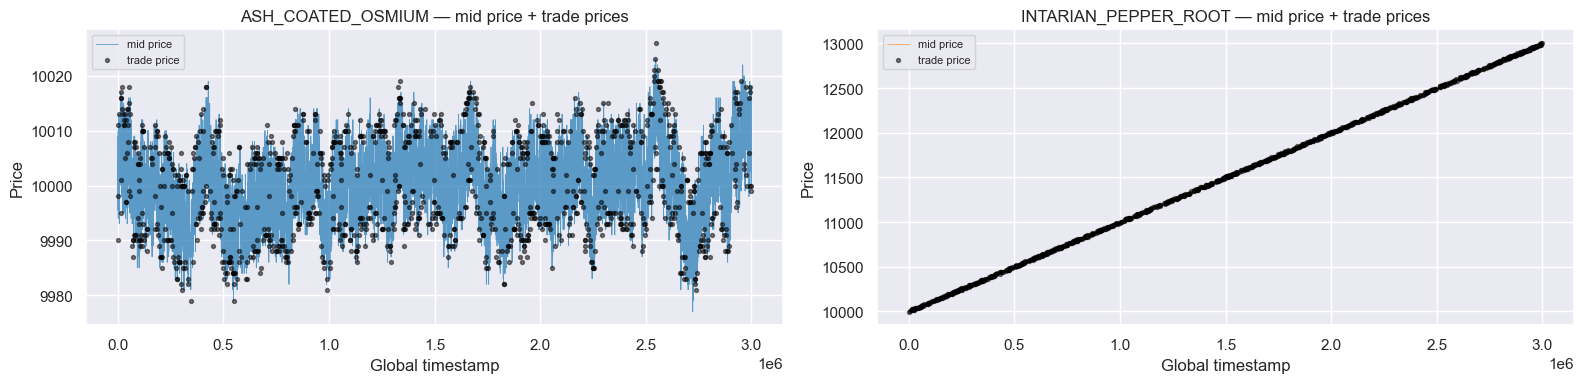

In [12]:
fig, axes = plt.subplots(1, len(products), figsize=(16, 4))

for ax, product, color in zip(axes, products, colors):
    df_t = trades[trades['symbol'] == product].sort_values('global_ts')
    df_p = prices[prices['product'] == product].sort_values('global_ts')
    ax.plot(df_p['global_ts'], df_p['mid_price'], lw=0.6, color=color, alpha=0.7, label='mid price')
    ax.scatter(df_t['global_ts'], df_t['price'], s=8, color='black', alpha=0.5, label='trade price', zorder=5)
    ax.set_title(f'{product} — mid price + trade prices')
    ax.set_xlabel('Global timestamp')
    ax.set_ylabel('Price')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 10. Trade volume distribution

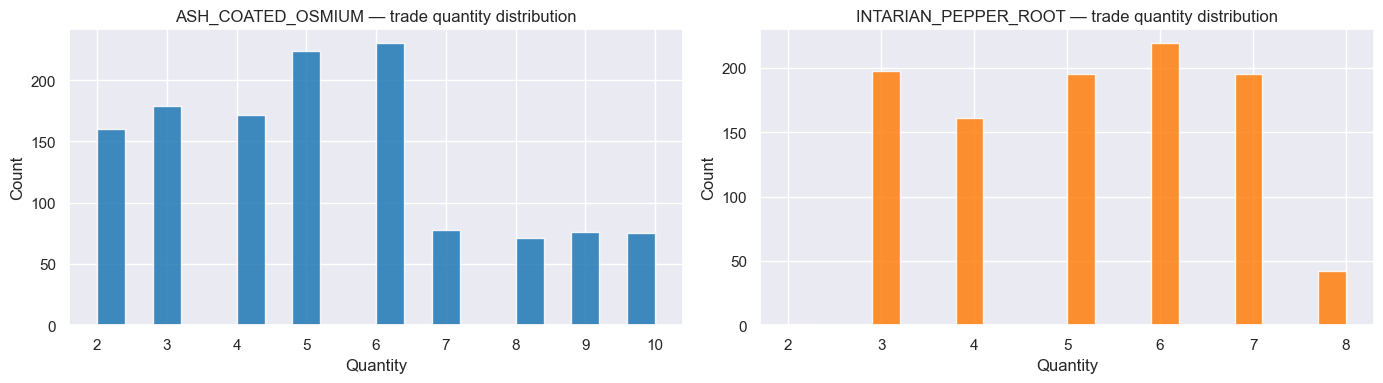

In [13]:
fig, axes = plt.subplots(1, len(products), figsize=(14, 4))

for ax, product, color in zip(axes, products, colors):
    df_t = trades[trades['symbol'] == product]
    ax.hist(df_t['quantity'], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{product} — trade quantity distribution')
    ax.set_xlabel('Quantity')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 11. Deep Trade Analysis

Covering:
1. **Data prep** — align each trade with the prevailing mid-price from the prices file
2. **Trade direction inference** (Lee-Ready / tick rule) → order-flow imbalance for Ash
3. **Recurring trade sizes** — detect bot fingerprints in both products
4. **Price impact (Kyle's λ)** — how much does signed volume move Ash mid-price?
5. **Pepper intraday trend shape** — linear drift or step jump per day?
6. **VWAP vs TWAP** — is Pepper's trend driven by buying pressure?
7. **Inter-trade arrival intervals** — clustering / burst detection
8. **Cross-product trade timing** — shared counterparty signal?

In [14]:
# ── 11.1  Data prep: attach prevailing mid-price to every trade ───────────────
ash_prices_ts = (
    prices[prices['product'] == 'ASH_COATED_OSMIUM'][['global_ts', 'mid_price']]
    .sort_values('global_ts').reset_index(drop=True)
)
pepper_prices_ts = (
    prices[prices['product'] == 'INTARIAN_PEPPER_ROOT'][['global_ts', 'mid_price']]
    .sort_values('global_ts').reset_index(drop=True)
)

ash_t   = trades[trades['symbol'] == 'ASH_COATED_OSMIUM'].sort_values('global_ts').copy()
pepper_t = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].sort_values('global_ts').copy()

# Last known mid-price before (or at) each trade timestamp
ash_t   = pd.merge_asof(ash_t,   ash_prices_ts,   on='global_ts', direction='backward')
pepper_t = pd.merge_asof(pepper_t, pepper_prices_ts, on='global_ts', direction='backward')

print('Ash trades with mid:', ash_t.shape)
print('Pepper trades with mid:', pepper_t.shape)
ash_t.head()

Ash trades with mid: (1265, 10)
Pepper trades with mid: (1011, 10)


,timestamp,buyer,seller,symbol,currency,price,quantity,day,global_ts,mid_price
0,700,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9990.0,6,-2,700,10000.5
1,900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9998.0,2,-2,900,9995.5
2,2500,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10011.0,8,-2,2500,10001.5
3,6100,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10013.0,8,-2,6100,10005.0
4,12900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10001.0,9,-2,12900,10001.0


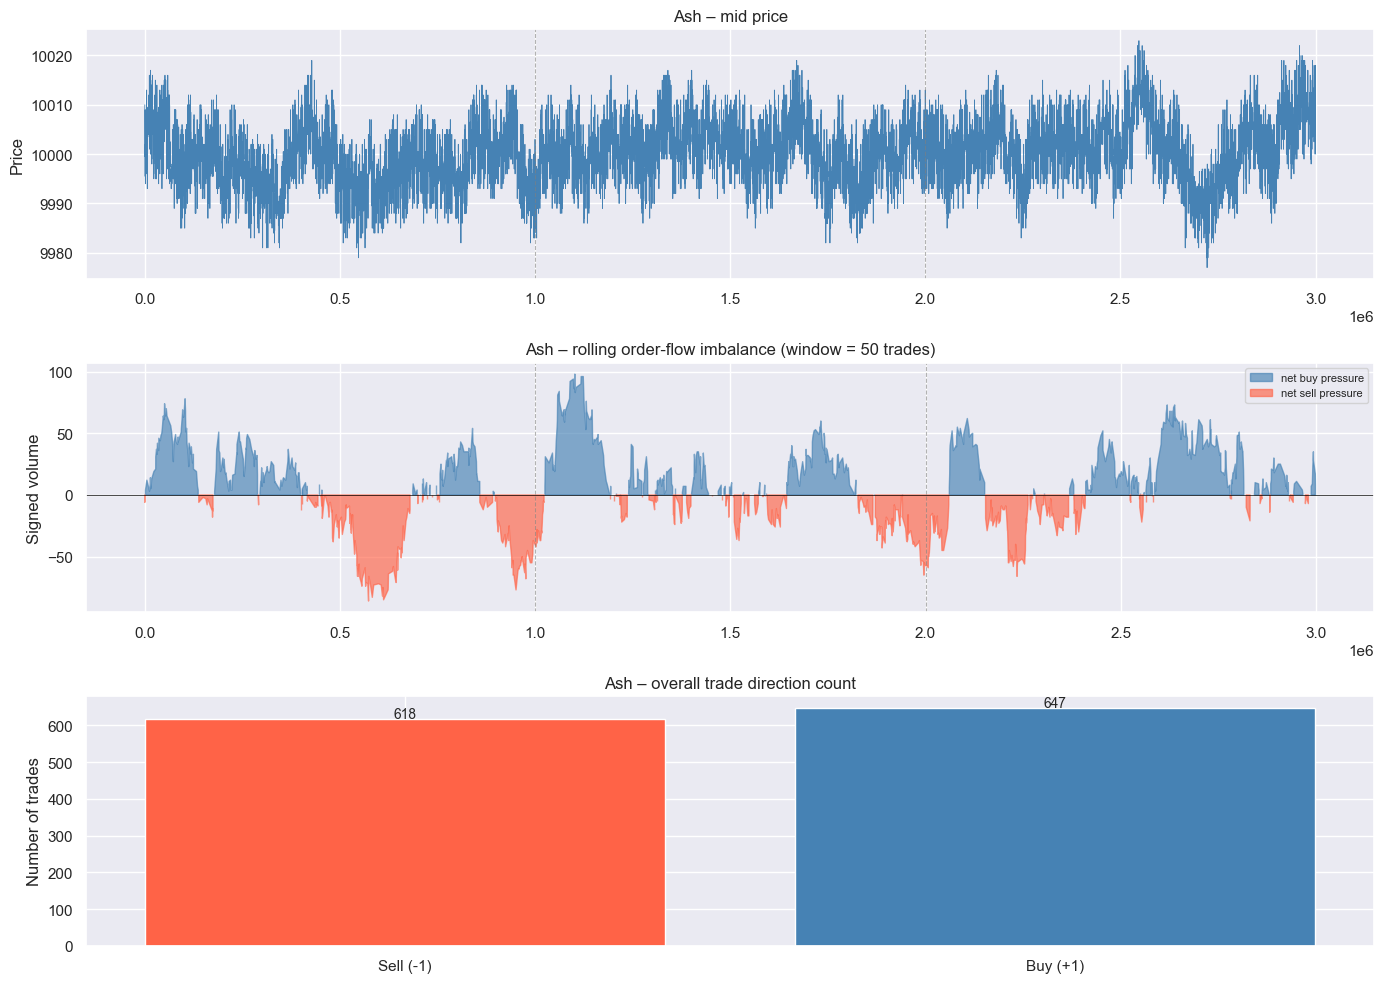


Ash direction split:
direction
Buy     647
Sell    618
Name: count, dtype: int64


In [15]:
# ── 11.2  Trade direction inference (Lee-Ready + tick rule) ──────────────────
def classify_direction(df: pd.DataFrame) -> pd.DataFrame:
    """
    Primary:  trade price vs prevailing mid  →  +1 buy / -1 sell
    Fallback: tick rule (sign of last price change) when price == mid
    """
    df = df.copy().reset_index(drop=True)
    cmp = np.sign(df['price'] - df['mid_price'])          # +1 / -1 / 0
    tick = np.sign(df['price'].diff()).replace(0, np.nan).ffill().fillna(1)
    df['direction'] = np.where(cmp != 0, cmp, tick).astype(int)
    df['signed_vol'] = df['direction'] * df['quantity']
    return df

ash_t    = classify_direction(ash_t)
pepper_t = classify_direction(pepper_t)

# Rolling order-flow imbalance (OFI) for Ash
OFI_WINDOW = 50
ash_t['ofi'] = ash_t['signed_vol'].rolling(OFI_WINDOW, min_periods=1).sum()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Mid price
ax = axes[0]
ap = prices[prices['product'] == 'ASH_COATED_OSMIUM'].sort_values('global_ts')
ax.plot(ap['global_ts'], ap['mid_price'], lw=0.6, color='steelblue')
for day in DAYS[1:]:
    ax.axvline((day + 2) * 1_000_000, color='gray', ls='--', lw=0.8, alpha=0.6)
ax.set_title('Ash – mid price')
ax.set_ylabel('Price')

# OFI over time
ax = axes[1]
ax.fill_between(ash_t['global_ts'], ash_t['ofi'],
                where=ash_t['ofi'] >= 0, color='steelblue', alpha=0.65, label='net buy pressure')
ax.fill_between(ash_t['global_ts'], ash_t['ofi'],
                where=ash_t['ofi'] <  0, color='tomato',    alpha=0.65, label='net sell pressure')
ax.axhline(0, color='black', lw=0.5)
for day in DAYS[1:]:
    ax.axvline((day + 2) * 1_000_000, color='gray', ls='--', lw=0.8, alpha=0.6)
ax.set_title(f'Ash – rolling order-flow imbalance (window = {OFI_WINDOW} trades)')
ax.set_ylabel('Signed volume')
ax.legend(fontsize=8)

# Direction breakdown bar
ax = axes[2]
counts = ash_t['direction'].value_counts().sort_index()
bar_colors = ['tomato' if k == -1 else 'steelblue' for k in counts.index]
ax.bar([{-1: 'Sell (-1)', 1: 'Buy (+1)'}.get(k, k) for k in counts.index],
       counts.values, color=bar_colors, edgecolor='white')
ax.set_title('Ash – overall trade direction count')
ax.set_ylabel('Number of trades')
for i, v in enumerate(counts.values):
    ax.text(i, v + 2, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print('\nAsh direction split:')
print(ash_t['direction'].value_counts().rename({1: 'Buy', -1: 'Sell'}))

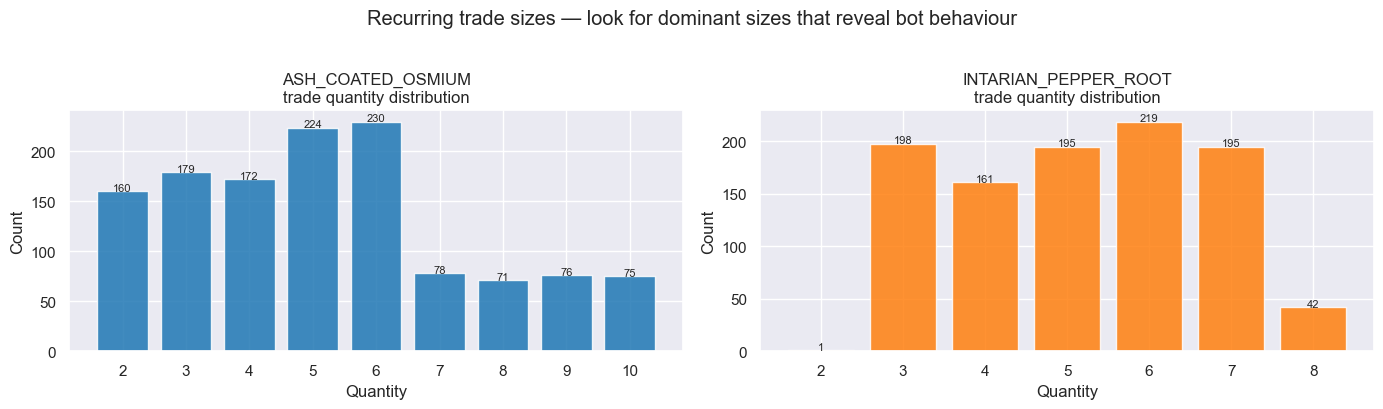

────────────────────────────────────────
ASH  top size: 6  (18.2% of trades)
      full breakdown: {6: 230, 5: 224, 3: 179, 4: 172, 2: 160, 7: 78, 9: 76, 10: 75, 8: 71}
PEPPER  top size: 6  (21.7% of trades)
      full breakdown: {6: 219, 3: 198, 7: 195, 5: 195, 4: 161, 8: 42, 2: 1}


In [16]:
# ── 11.3  Recurring trade sizes — bot fingerprinting ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (label, df_t), color in zip(axes,
    [('ASH_COATED_OSMIUM', ash_t), ('INTARIAN_PEPPER_ROOT', pepper_t)], colors):

    counts = df_t['quantity'].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{label}\ntrade quantity distribution')
    ax.set_xlabel('Quantity')
    ax.set_ylabel('Count')
    # Annotate every bar with its count
    for qty, cnt in counts.items():
        ax.text(str(qty), cnt + 0.5, str(cnt), ha='center', fontsize=8)

plt.suptitle('Recurring trade sizes — look for dominant sizes that reveal bot behaviour', y=1.02)
plt.tight_layout()
plt.show()

print('─' * 40)
for label, df_t in [('ASH', ash_t), ('PEPPER', pepper_t)]:
    vc = df_t['quantity'].value_counts()
    top_pct = vc.iloc[0] / len(df_t) * 100
    print(f"{label}  top size: {vc.index[0]}  ({top_pct:.1f}% of trades)")
    print(f"      full breakdown: {vc.to_dict()}")

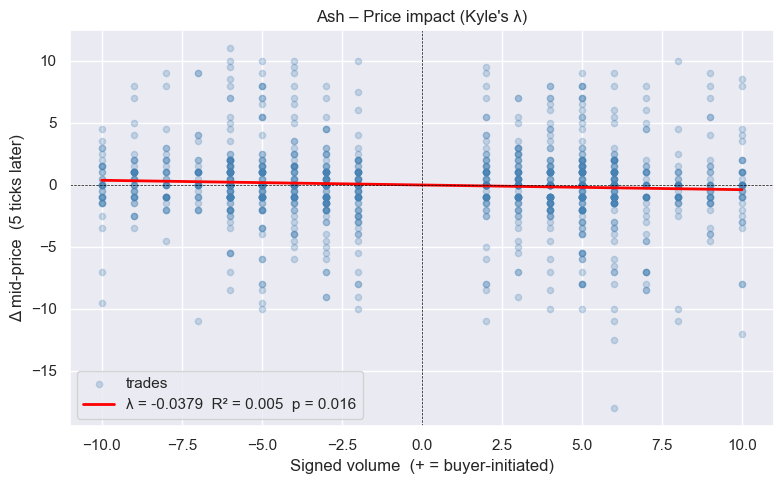


Kyle's λ = -0.03787  (R²=0.0046, p=0.0156)
Each unit of signed volume shifts the mid by -0.0379 ticks on average.
→ Very low price impact: adverse selection risk is minimal — tight quoting is safe.


In [17]:
# ── 11.4  Price impact — Kyle's λ (Ash) ──────────────────────────────────────
# For each trade: measure how much the mid-price moves N ticks later.
# Regress Δmid on signed volume → slope is Kyle's lambda.
LAG_TICKS = 5   # 5 price rows = 500 ms

ash_mid_full = (
    prices[prices['product'] == 'ASH_COATED_OSMIUM']
    .sort_values('global_ts').reset_index(drop=True)
    [['global_ts', 'mid_price']]
)
ash_mid_full['mid_future'] = ash_mid_full['mid_price'].shift(-LAG_TICKS)

# Attach future mid to each trade
impact = pd.merge_asof(
    ash_t.sort_values('global_ts'),
    ash_mid_full[['global_ts', 'mid_future']],
    on='global_ts', direction='backward'
).dropna(subset=['mid_future', 'mid_price'])

impact['delta_mid'] = impact['mid_future'] - impact['mid_price']

from scipy.stats import linregress
slope, intercept, r, p_val, se = linregress(impact['signed_vol'], impact['delta_mid'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(impact['signed_vol'], impact['delta_mid'],
           alpha=0.25, s=20, color='steelblue', label='trades')
x_fit = np.linspace(impact['signed_vol'].min(), impact['signed_vol'].max(), 200)
ax.plot(x_fit, intercept + slope * x_fit, color='red', lw=2,
        label=f"λ = {slope:.4f}  R² = {r**2:.3f}  p = {p_val:.3f}")
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.axvline(0, color='black', lw=0.5, ls='--')
ax.set_xlabel('Signed volume  (+ = buyer-initiated)')
ax.set_ylabel(f'Δ mid-price  ({LAG_TICKS} ticks later)')
ax.set_title("Ash – Price impact (Kyle's λ)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nKyle's λ = {slope:.5f}  (R²={r**2:.4f}, p={p_val:.4f})")
print(f"Each unit of signed volume shifts the mid by {slope:.4f} ticks on average.")
if abs(slope) < 0.05:
    print("→ Very low price impact: adverse selection risk is minimal — tight quoting is safe.")

Pepper linear fit per day:
  Day -2:  slope = 0.00100 per ts   (999.3 total pts drift)   R² = 1.000
  Day -1:  slope = 0.00100 per ts   (999.6 total pts drift)   R² = 1.000
  Day +0:  slope = 0.00100 per ts   (999.4 total pts drift)   R² = 1.000


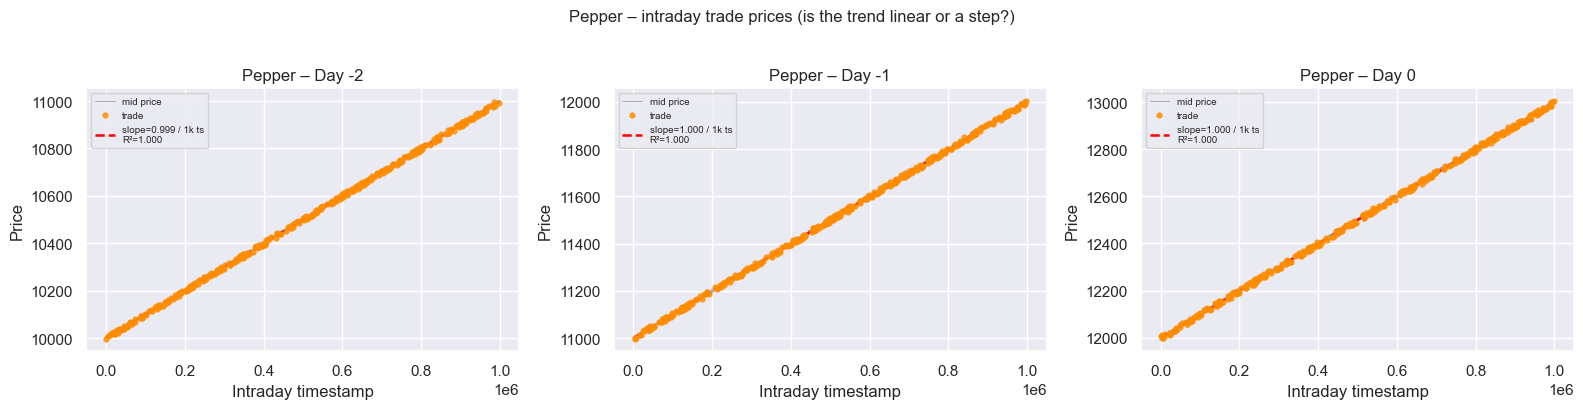

In [18]:
# ── 11.5  Pepper – intraday trend shape: linear drift or step jump? ──────────
from scipy.stats import linregress as lr_fn

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

print("Pepper linear fit per day:")
for ax, day in zip(axes, DAYS):
    df_t = pepper_t[pepper_t['day'] == day].sort_values('timestamp')
    df_p = prices[(prices['product'] == 'INTARIAN_PEPPER_ROOT') &
                  (prices['day'] == day)].sort_values('timestamp')

    ax.plot(df_p['timestamp'], df_p['mid_price'],
            lw=0.7, color='gray', alpha=0.6, label='mid price')
    ax.scatter(df_t['timestamp'], df_t['price'],
               s=12, color='darkorange', alpha=0.8, zorder=5, label='trade')

    if len(df_t) > 2:
        sl, ic, r, pv, _ = lr_fn(df_t['timestamp'], df_t['price'])
        x_fit = np.array([df_t['timestamp'].min(), df_t['timestamp'].max()])
        ax.plot(x_fit, ic + sl * x_fit, color='red', lw=1.8, ls='--',
                label=f'slope={sl*1000:.3f} / 1k ts\nR²={r**2:.3f}')
        print(f"  Day {day:+d}:  slope = {sl:.5f} per ts   "
              f"({sl * 999_900:.1f} total pts drift)   R² = {r**2:.3f}")

    ax.set_title(f'Pepper – Day {day}')
    ax.set_xlabel('Intraday timestamp')
    ax.set_ylabel('Price')
    ax.legend(fontsize=7)

plt.suptitle('Pepper – intraday trade prices (is the trend linear or a step?)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

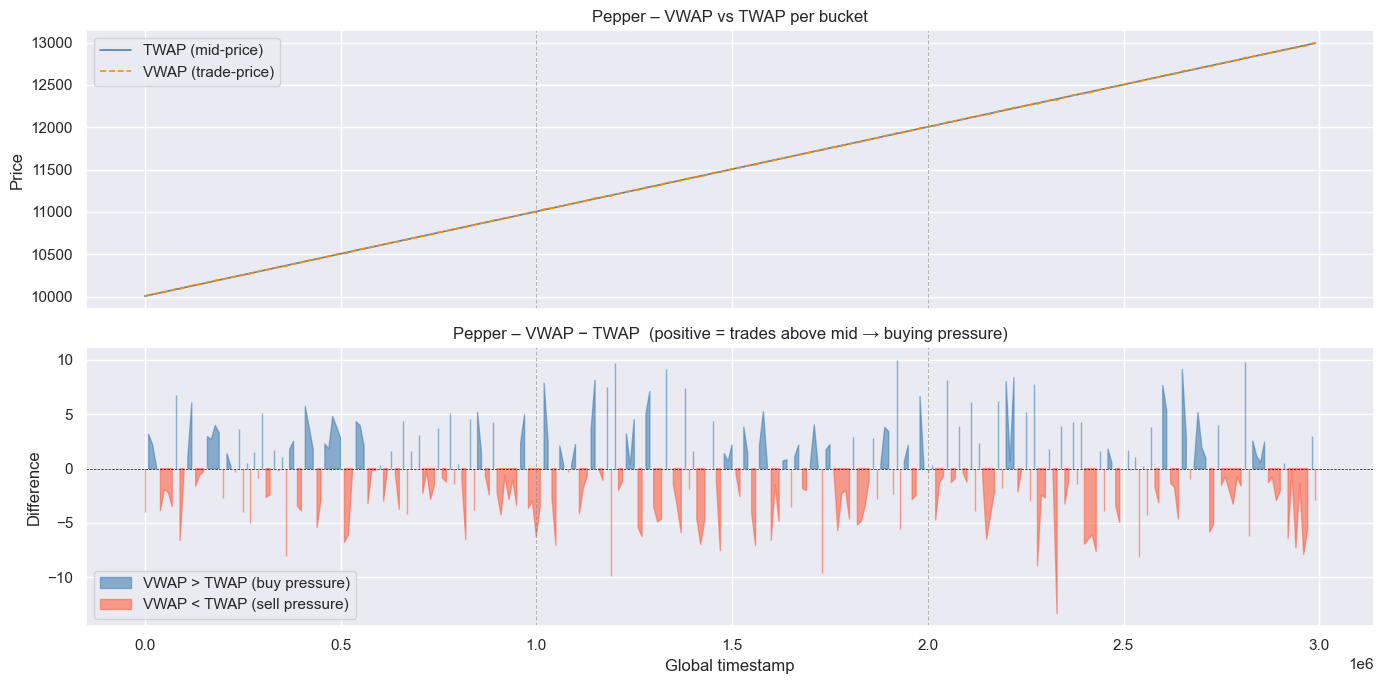

VWAP − TWAP stats:
count    293.000
mean      -0.378
std        4.021
min      -13.325
25%       -3.000
50%       -0.556
75%        2.170
max        9.965
Name: diff, dtype: float64

Fraction of buckets where VWAP > TWAP: 43.3%


In [19]:
# ── 11.6  Pepper – VWAP vs TWAP ───────────────────────────────────────────────
# TWAP: time-weighted average of mid-price in each bucket
# VWAP: volume-weighted average of trade prices in each bucket
# If VWAP > TWAP consistently → trades happen above fair value → buying pressure is driving the trend

BUCKET = 10_000

pepper_t['bucket']  = (pepper_t['global_ts']  // BUCKET) * BUCKET
pep_prices_all = prices[prices['product'] == 'INTARIAN_PEPPER_ROOT'].copy()
pep_prices_all['bucket'] = (pep_prices_all['global_ts'] // BUCKET) * BUCKET

vwap = (pepper_t.groupby('bucket')
        .apply(lambda x: (x['price'] * x['quantity']).sum() / x['quantity'].sum(), include_groups=False)
        .reset_index(name='vwap'))

twap = (pep_prices_all.groupby('bucket')['mid_price']
        .mean().reset_index(name='twap'))

vt = pd.merge(vwap, twap, on='bucket', how='inner')
vt['diff'] = vt['vwap'] - vt['twap']

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(vt['bucket'], vt['twap'],  label='TWAP (mid-price)',  color='steelblue', lw=1.2)
axes[0].plot(vt['bucket'], vt['vwap'],  label='VWAP (trade-price)', color='darkorange', lw=1.2, ls='--')
for day in DAYS[1:]:
    axes[0].axvline((day + 2) * 1_000_000, color='gray', ls='--', lw=0.8, alpha=0.6)
axes[0].set_title('Pepper – VWAP vs TWAP per bucket')
axes[0].set_ylabel('Price')
axes[0].legend()

axes[1].fill_between(vt['bucket'], vt['diff'],
                     where=vt['diff'] >= 0, color='steelblue', alpha=0.6, label='VWAP > TWAP (buy pressure)')
axes[1].fill_between(vt['bucket'], vt['diff'],
                     where=vt['diff'] <  0, color='tomato',    alpha=0.6, label='VWAP < TWAP (sell pressure)')
axes[1].axhline(0, color='black', lw=0.5, ls='--')
for day in DAYS[1:]:
    axes[1].axvline((day + 2) * 1_000_000, color='gray', ls='--', lw=0.8, alpha=0.6)
axes[1].set_title('Pepper – VWAP − TWAP  (positive = trades above mid → buying pressure)')
axes[1].set_ylabel('Difference')
axes[1].set_xlabel('Global timestamp')
axes[1].legend()

plt.tight_layout()
plt.show()

print("VWAP − TWAP stats:")
print(vt['diff'].describe().round(3))
print(f"\nFraction of buckets where VWAP > TWAP: {(vt['diff'] > 0).mean():.1%}")


ASH_COATED_OSMIUM inter-trade intervals:
count     1264.0
mean      2371.6
std       2432.0
min          0.0
25%        700.0
50%       1600.0
75%       3100.0
max      18300.0
Name: global_ts, dtype: float64

INTARIAN_PEPPER_ROOT inter-trade intervals:
count     1010.0
mean      2967.7
std       2791.2
min          0.0
25%        900.0
50%       2200.0
75%       4000.0
max      19100.0
Name: global_ts, dtype: float64


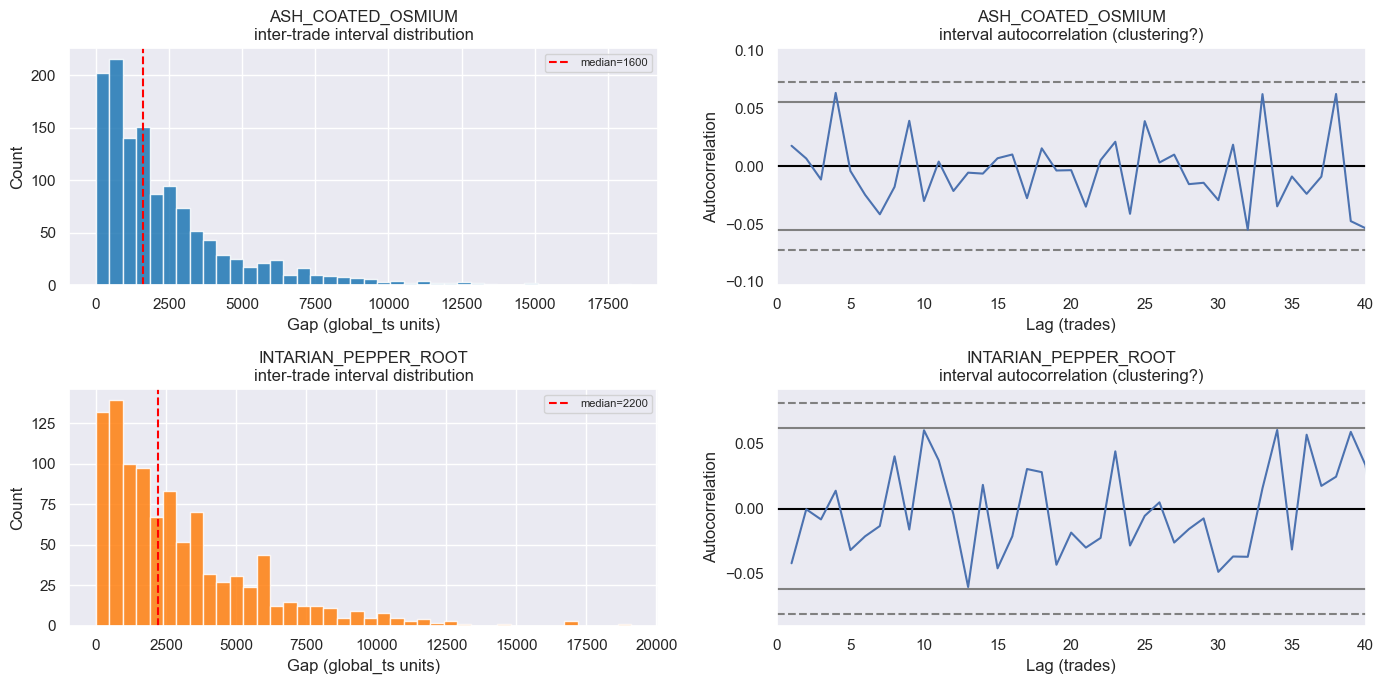

In [20]:
# ── 11.7  Inter-trade arrival intervals — burst / clustering detection ────────
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

for row, (label, df_t) in enumerate([('ASH_COATED_OSMIUM', ash_t),
                                      ('INTARIAN_PEPPER_ROOT', pepper_t)]):
    intervals = df_t.sort_values('global_ts')['global_ts'].diff().dropna()

    # Distribution
    axes[row, 0].hist(intervals, bins=40, color=colors[row], edgecolor='white', alpha=0.85)
    axes[row, 0].set_title(f'{label}\ninter-trade interval distribution')
    axes[row, 0].set_xlabel('Gap (global_ts units)')
    axes[row, 0].set_ylabel('Count')
    med = intervals.median()
    axes[row, 0].axvline(med, color='red', lw=1.5, ls='--', label=f'median={med:.0f}')
    axes[row, 0].legend(fontsize=8)

    # Autocorrelation (do short gaps follow short gaps? = clustering)
    pd.plotting.autocorrelation_plot(intervals.reset_index(drop=True), ax=axes[row, 1])
    axes[row, 1].set_title(f'{label}\ninterval autocorrelation (clustering?)')
    axes[row, 1].set_xlim(0, 40)
    axes[row, 1].set_xlabel('Lag (trades)')

    print(f"\n{label} inter-trade intervals:")
    print(intervals.describe().round(1))

plt.tight_layout()
plt.show()

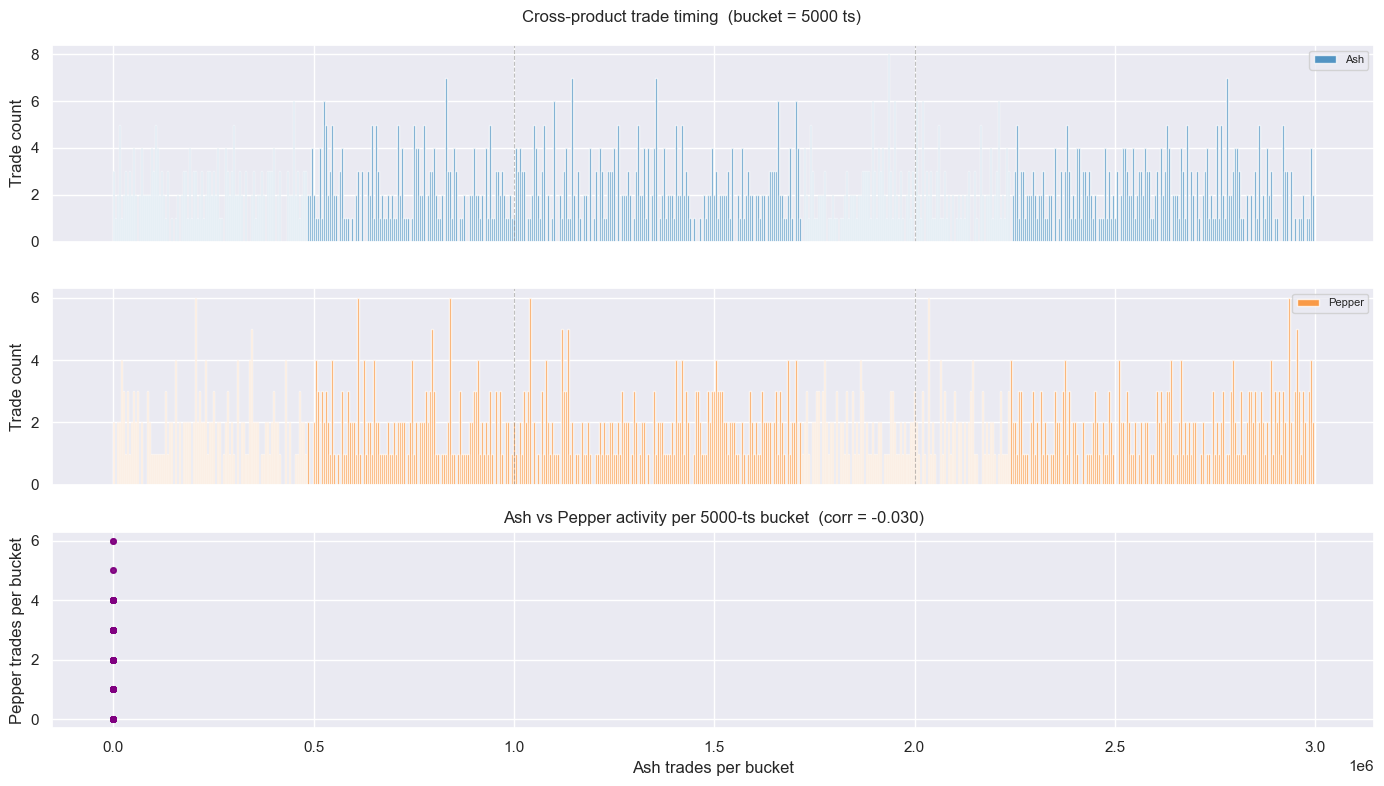

Pearson correlation of per-bucket trade counts: -0.0303
→ Low co-activity: products appear to be traded independently.


In [21]:
# ── 11.8  Cross-product trade timing — shared counterparty? ──────────────────
# If Ash and Pepper trade activity spikes at the same timestamps,
# it suggests a single bot operating in both markets simultaneously.

BUCKET = 5_000

ash_b   = ash_t.copy();   ash_b['bucket']   = (ash_b['global_ts']   // BUCKET) * BUCKET
pepper_b = pepper_t.copy(); pepper_b['bucket'] = (pepper_b['global_ts'] // BUCKET) * BUCKET

ash_cnt   = ash_b.groupby('bucket').size().rename('ash')
pepper_cnt = pepper_b.groupby('bucket').size().rename('pepper')
joint = pd.concat([ash_cnt, pepper_cnt], axis=1).fillna(0)

corr_val = joint.corr().loc['ash', 'pepper']

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].bar(joint.index, joint['ash'],    width=BUCKET*0.85, color=colors[0], alpha=0.75, label='Ash')
axes[1].bar(joint.index, joint['pepper'], width=BUCKET*0.85, color=colors[1], alpha=0.75, label='Pepper')
for ax in axes[:2]:
    for day in DAYS[1:]:
        ax.axvline((day + 2) * 1_000_000, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.legend(fontsize=8); ax.set_ylabel('Trade count')

# Scatter: Ash count vs Pepper count per bucket
axes[2].scatter(joint['ash'], joint['pepper'], alpha=0.4, s=15, color='purple')
axes[2].set_xlabel('Ash trades per bucket')
axes[2].set_ylabel('Pepper trades per bucket')
axes[2].set_title(f'Ash vs Pepper activity per {BUCKET}-ts bucket  (corr = {corr_val:.3f})')

fig.suptitle(f'Cross-product trade timing  (bucket = {BUCKET} ts)', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Pearson correlation of per-bucket trade counts: {corr_val:.4f}")
if abs(corr_val) > 0.3:
    print("→ Moderate-to-strong co-activity: likely a shared counterparty or time-of-day effect.")
else:
    print("→ Low co-activity: products appear to be traded independently.")